# Problem Definition

Heart disease can be difficult to identify early without medical testing. ECG images contain important information about the heart's electrical activity.

The objective of this project is to build a neural network model that can classify ECG images into different heart condition classes.

The model will take an ECG image as input and predict the correct class.

# Dataset Selection

The dataset used in this project is the ECG Image Dataset from Kaggle.

The dataset contains ECG images divided into 4 classes:
1. Myocardial Infarction
2. History of MI
3. Abnormal Heartbeat
4. Normal

Features:
The features are the pixel values of the ECG images.

Target variable:
The target variable is the ECG image class.

Number of images:
The dataset contains 3023 training images and 928 testing images.

In [141]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

In [142]:
train_path = "/kaggle/input/datasets/kanishkarathore1604/ecg-image/ECG_DATA/train"
test_path = "/kaggle/input/datasets/kanishkarathore1604/ecg-image/ECG_DATA/test"

In [143]:
img_size = (128, 128)
batch_size = 32

image_paths = []
labels = []

folder_names = sorted([folder.name for folder in Path(train_path).iterdir() if folder.is_dir()])

for label_number, folder_name in enumerate(folder_names):
    folder_path = Path(train_path) / folder_name
    
    for image_file in folder_path.glob("*"):
        image_paths.append(str(image_file))
        labels.append(label_number)

In [144]:
train_files, val_files, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

In [145]:
def load_image(image_path, label):
    image = tf.io.read_file(image_path)
    image = tf.image.decode_image(image, channels=3)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, img_size)
    image = tf.cast(image, tf.float32)
    label = tf.one_hot(label, 4)
    
    return image, label

In [146]:
train_data = tf.data.Dataset.from_tensor_slices((train_files, train_labels))
train_data = train_data.map(load_image)
train_data = train_data.batch(batch_size)

val_data = tf.data.Dataset.from_tensor_slices((val_files, val_labels))
val_data = val_data.map(load_image)
val_data = val_data.batch(batch_size)

In [147]:
test_data = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='categorical',
    class_names=folder_names
)

Found 928 files belonging to 4 classes.


In [148]:
class_names = [
    "Myocardial Infarction",
    "History of MI",
    "Abnormal Heartbeat",
    "Normal"
]

print(class_names)

['Myocardial Infarction', 'History of MI', 'Abnormal Heartbeat', 'Normal']


In [149]:
train_data = train_data.map(lambda x, y: (x / 255, y))
val_data = val_data.map(lambda x, y: (x / 255, y))
test_data = test_data.map(lambda x, y: (x / 255, y))

In [150]:
for images, labels in train_data.take(1):
    print("Minimum pixel value:", images.numpy().min())
    print("Maximum pixel value:", images.numpy().max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


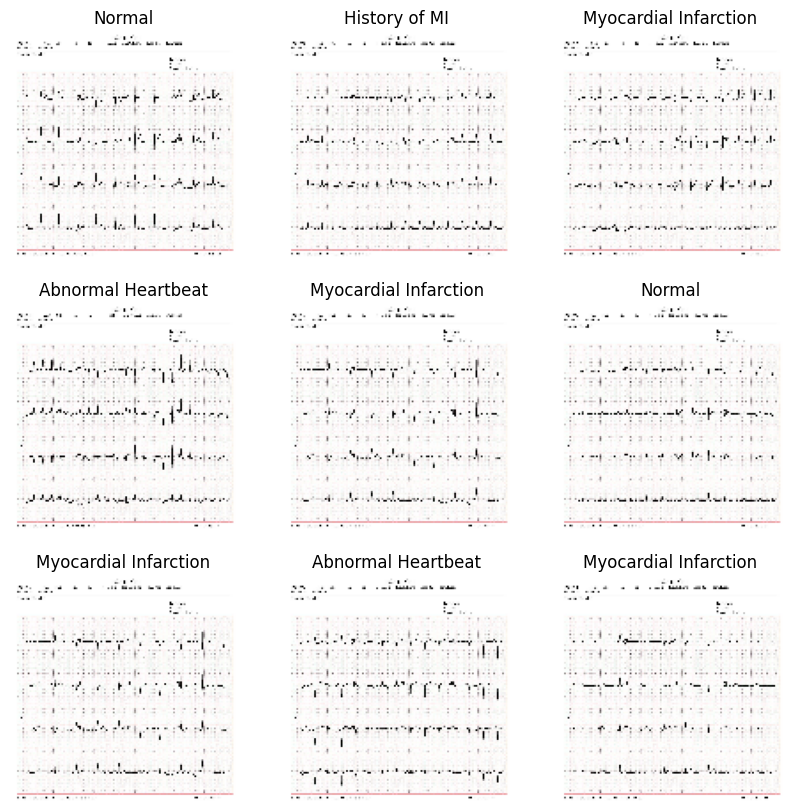

In [151]:
plt.figure(figsize=(10, 10))

for images, labels in train_data.take(1):
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i])
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis("off")

plt.show()

In [152]:
train_counts = np.zeros(len(class_names))
test_counts = np.zeros(len(class_names))

for images, labels in train_data:
    train_counts += labels.numpy().sum(axis=0)

for images, labels in test_data:
    test_counts += labels.numpy().sum(axis=0)

class_distribution = pd.DataFrame({
    "Class": class_names,
    "Training Images": train_counts.astype(int),
    "Testing Images": test_counts.astype(int)
})

class_distribution["Total Images"] = class_distribution["Training Images"] + class_distribution["Testing Images"]

class_distribution

,Class,Training Images,Testing Images,Total Images
0,Myocardial Infarction,765,239,1004
1,History of MI,413,172,585
2,Abnormal Heartbeat,559,233,792
3,Normal,681,284,965


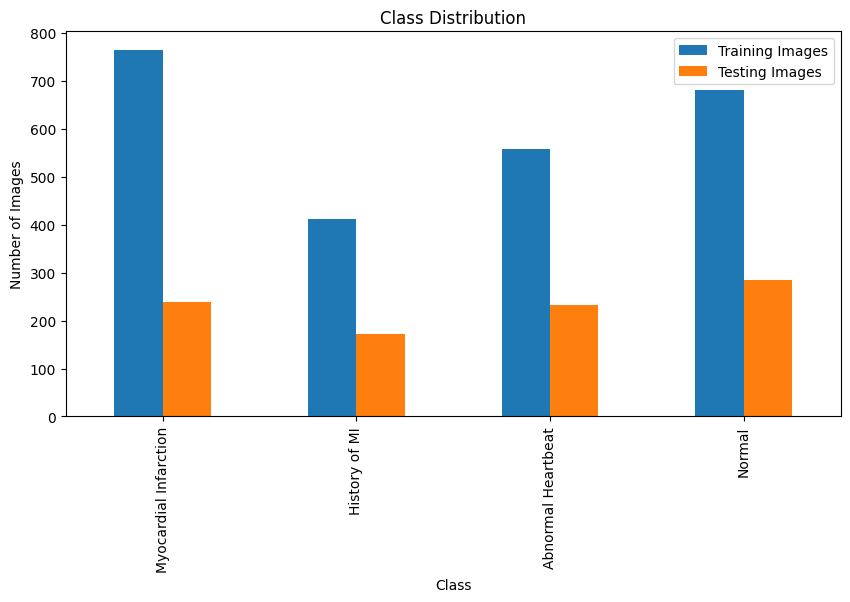

In [153]:
class_distribution.plot(
    x="Class",
    y=["Training Images", "Testing Images"],
    kind="bar",
    figsize=(10, 5)
)

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

In [154]:
class_distribution[["Training Images", "Testing Images", "Total Images"]].describe()

,Training Images,Testing Images,Total Images
count,4.00000,4.000000,4.000000
mean,604.50000,232.000000,836.500000
std,153.13937,46.021734,191.312136
min,413.00000,172.000000,585.000000
25%,522.50000,217.750000,740.250000
50%,620.00000,236.000000,878.500000
75%,702.00000,250.250000,974.750000
max,765.00000,284.000000,1004.000000


# EDA Summary

1. The dataset contains 4 ECG image classes.
2. The images are divided into training and testing folders.
3. The class distribution table shows the number of images in each class.
4. The bar chart compares the number of training and testing images.
5. The dataset contains ECG images that will be used for diagnosing.

# Preprocessing Summary

1. Missing values: The dataset has images so there are no missing values
2. Encoding: class labels were automatically encoded from folder names since we used categorical label mode.
3. Resizing: Images were resized to 128 × 128 pixels.
4. Normalization: Pixel values were divided by 255 to become between 0 and 1.
5. Splitting: The dataset was already split into training and testing folders.

In [155]:
deep_model = Sequential([
    Flatten(input_shape=(128, 128, 3)),
    
    Dense(256, activation="relu"),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    
    Dense(4, activation="softmax")
])

deep_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_7 (Flatten)             │ (None, 49152)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 256)            │    12,583,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,624,580 (48.16 MB)

 Trainable params: 12,624,580 (48.16 MB)

 Non-trainable params: 0 (0.00 B)

In [156]:
deep_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [157]:
history = deep_model.fit(
    train_data,
    epochs=13,
    validation_data = val_data
)

Epoch 1/13
76/76 ━━━━━━━━━━━━━━━━━━━━ 21s 244ms/step - accuracy: 0.2775 - loss: 6.6890 - val_accuracy: 0.3157 - val_loss: 3.7175
Epoch 2/13
76/76 ━━━━━━━━━━━━━━━━━━━━ 18s 241ms/step - accuracy: 0.2903 - loss: 1.9918 - val_accuracy: 0.2826 - val_loss: 1.8197
Epoch 3/13
76/76 ━━━━━━━━━━━━━━━━━━━━ 18s 233ms/step - accuracy: 0.3457 - loss: 2.3615 - val_accuracy: 0.2826 - val_loss: 2.4640
Epoch 4/13
76/76 ━━━━━━━━━━━━━━━━━━━━ 20s 266ms/step - accuracy: 0.3801 - loss: 1.5011 - val_accuracy: 0.4050 - val_loss: 1.4817
Epoch 5/13
76/76 ━━━━━━━━━━━━━━━━━━━━ 19s 253ms/step - accuracy: 0.4673 - loss: 1.2239 - val_accuracy: 0.3372 - val_loss: 1.3332
Epoch 6/13
76/76 ━━━━━━━━━━━━━━━━━━━━ 18s 233ms/step - accuracy: 0.5132 - loss: 1.0858 - val_accuracy: 0.5983 - val_loss: 0.9337
Epoch 7/13
76/76 ━━━━━━━━━━━━━━━━━━━━ 18s 239ms/step - accuracy: 0.6183 - loss: 0.9493 - val_accuracy: 0.6066 - val_loss: 0.8558
Epoch 8/13
76/76 ━━━━━━━━━━━━━━━━━━━━ 18s 237ms/step - accuracy: 0.6472 - loss: 0.8714 - val_accu

In [158]:
print(history.epoch)
print(len(history.history['loss']))

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
13


# Model choice

We used MLP since our data consists of images .Other machine learning models such as Logistic Regression, Decision Tree, Random Forest, KNN, and SVM are more suitable for tabular data. Since this project uses ECG images, a neural network is more suitable.

However, MLP has a limitation because it does not understand image position and spatial patterns as well as CNN models. Therefore, the model may not be perfect, but it is suitable for this project requirement.

In [159]:
test_loss, test_accuracy = deep_model.evaluate(test_data)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

29/29 ━━━━━━━━━━━━━━━━━━━━ 6s 190ms/step - accuracy: 0.7091 - loss: 0.6615
Test Loss: 0.6614710092544556
Test Accuracy: 0.7090517282485962


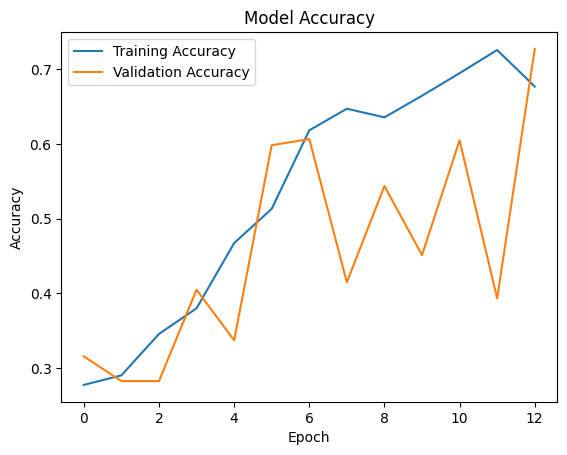

In [160]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.show()

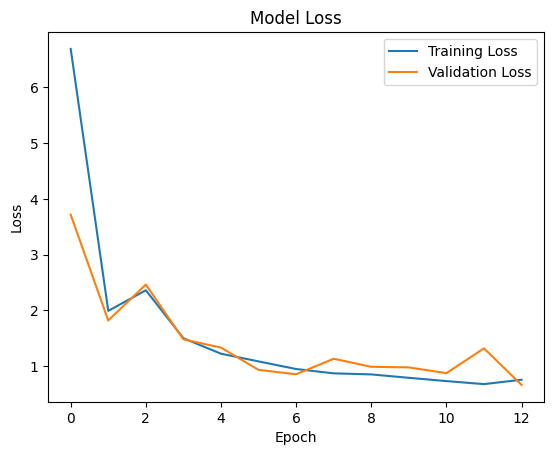

In [161]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Training Loss', 'Validation Loss'])
plt.show()

# Evaluation summary

The model was evaluated using test accuracy and test loss.

Test accuracy shows how many ECG images were classified correctly.

Test loss shows the error of the model predictions.

The accuracy and loss graphs show how the model performance changed during training.

In [162]:
deep_model.save("ecg_mlp_model.keras")